STEP W5: PUBLICATION PACKAGE — WEATHER EXTENSION
Mounted at /content/drive

Required weather files:
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_test_leaderboard.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_validation_comparison.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_paired_block_bootstrap.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_paired_hac_tests.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_feature_group_ablation.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_hourly_comparison.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_monthly_effect.csv -> True
/content/drive/MyDrive/Load_Forecasting_Paper/results/weather_extension/weather_daily_paired_errors.csv -> True
/content/

,Model,Status,Load_History_Features,Calendar_Features,Weather_Features,Total_Features,Alpha,Test_MAE_MW,Test_RMSE_MW,Test_MAPE_percent
0,Frozen Ridge,Primary final model,151,14,0,165,10.0,437.1565,648.5674,3.7784
1,Ridge + Historical Weather,Extension / ablation only,151,14,89,254,10.0,445.8748,652.7949,3.8626



TABLE 2 — WEATHER EXTENSION


,Model,Features,Validation_MAE_MW,Test_MAE_MW,Test_RMSE_MW,Test_MAPE_percent,Test_MAE_Improvement_vs_Frozen_MW,Relative_Test_Skill_percent
0,Frozen Ridge,165,409.5962,437.1565,648.5674,3.7784,0.0000,0.0000
1,Ridge + Historical Weather,254,397.8412,445.8748,652.7949,3.8626,-8.7183,-1.9943



TABLE 3 — WEATHER STATISTICAL EVIDENCE


,Method,Mean_Difference_MW,CI_Lower_MW,CI_Upper_MW,P_Value,Interpretation
0,7-day moving-block bootstrap,-8.71825,-16.87574,-0.64368,NaN,95% CI below zero; historical-weather model ha...
1,14-day moving-block bootstrap,-8.71825,-17.74543,-0.14013,NaN,95% CI below zero; deterioration persists unde...
2,Newey-West HAC lag 7,-8.71825,NaN,NaN,0.03989,Evidence against zero mean loss difference at ...
3,Newey-West HAC lag 14,-8.71825,NaN,NaN,0.05834,Does not cross the conventional 5% significanc...



TABLE 4 — POST-HOC WEATHER ABLATION


,Removed_Group,Features_Remaining,Validation_MAE_MW,Test_MAE_MW,Test_RMSE_MW,Test_MAPE_percent,Delta_Validation_MAE_vs_FullWeather_MW,Delta_Test_MAE_vs_FullWeather_MW
0,NaN,254,397.8412,445.8748,652.7949,3.8626,0.0000,0.0000
1,Previous_Day_Daily_Weather,240,398.3897,442.3746,649.5171,3.8336,0.5485,-3.5002
2,Previous_Day_Hourly_Temperature,230,398.6704,446.7531,653.0069,3.8658,0.8292,0.8783
3,Previous_Day_Hourly_Humidity,230,395.4293,443.0490,651.0715,3.8312,-2.4119,-2.8258
4,Weather_Rolling7_Mean,246,396.8512,445.1838,650.7247,3.8580,-0.9900,-0.6910
5,Weather_Rolling28_Mean,246,398.1611,443.2863,651.5273,3.8385,0.3199,-2.5885
6,Weather_Rolling7_STD,250,398.7223,446.1774,653.4753,3.8650,0.8811,0.3026
7,Weather_Rolling28_STD,250,403.0656,438.4272,648.2781,3.7922,5.2244,-7.4476
8,Weather_Availability,251,397.8418,445.8754,652.7958,3.8626,0.0005,0.0006
9,All_Weather,165,409.5962,437.1565,648.5674,3.7784,11.7549,-8.7183



Excel workbook created:
/content/drive/MyDrive/Load_Forecasting_Paper/results/publication_package_weather_extension/weather_extension_publication_tables.xlsx


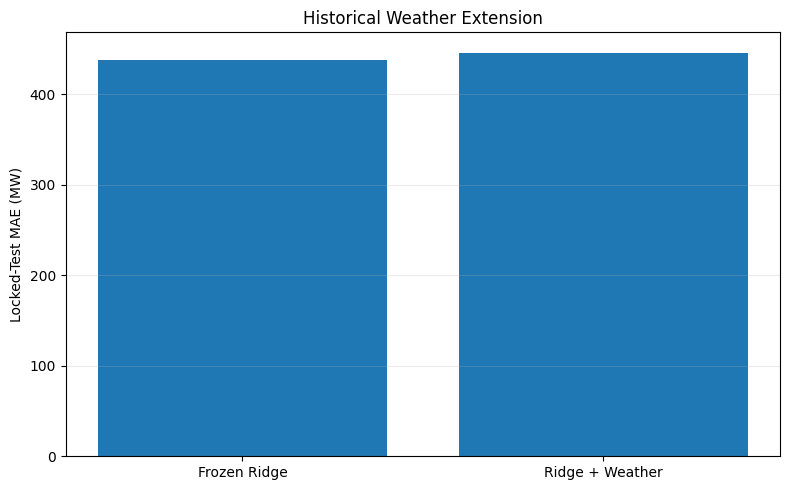

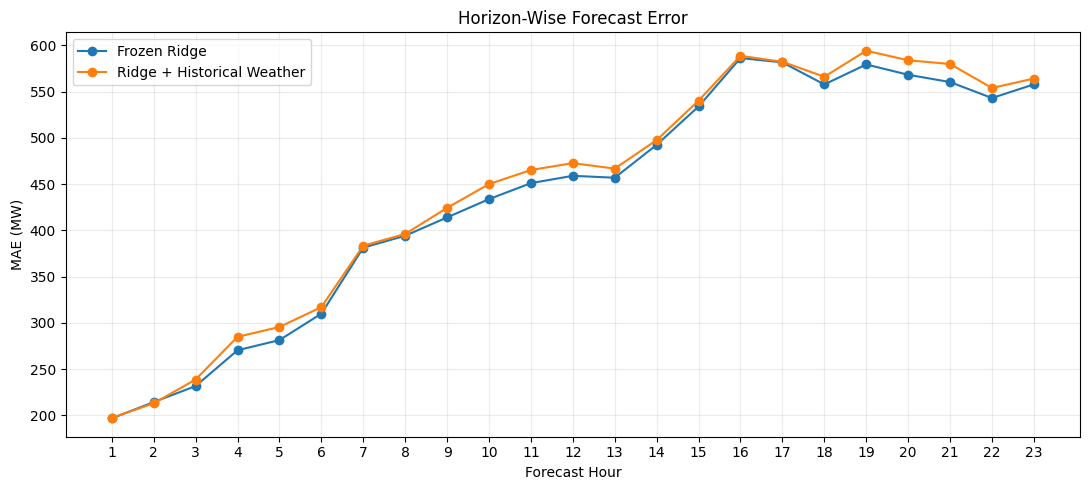

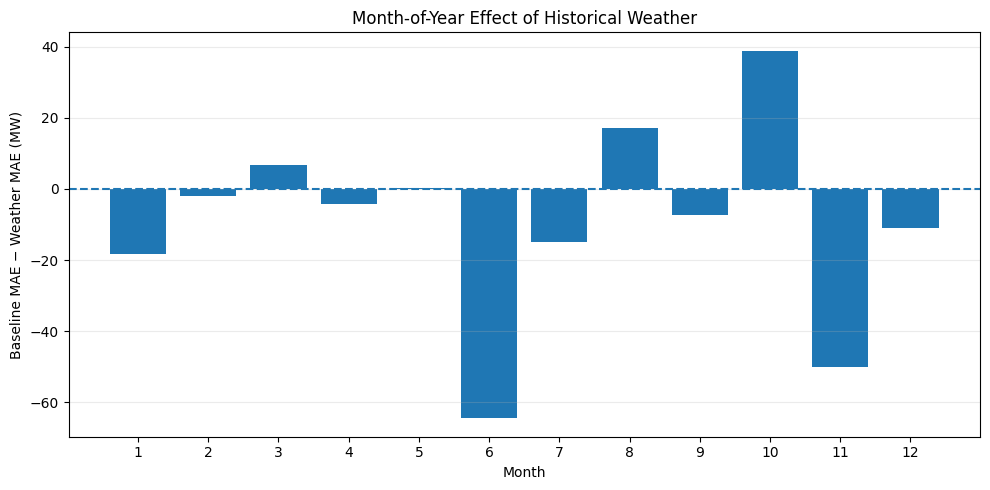

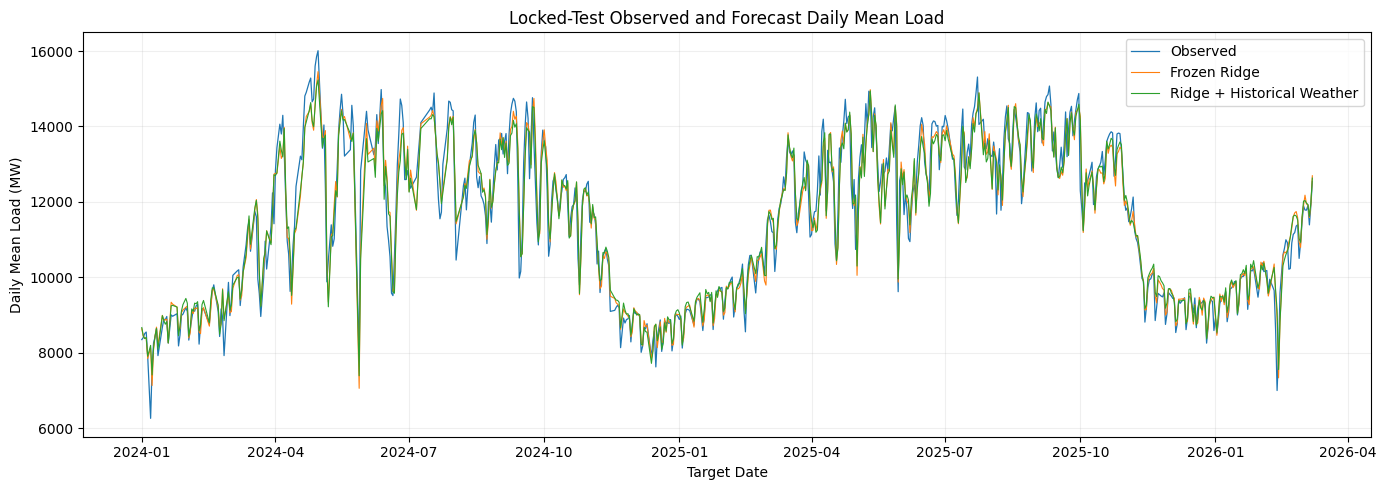

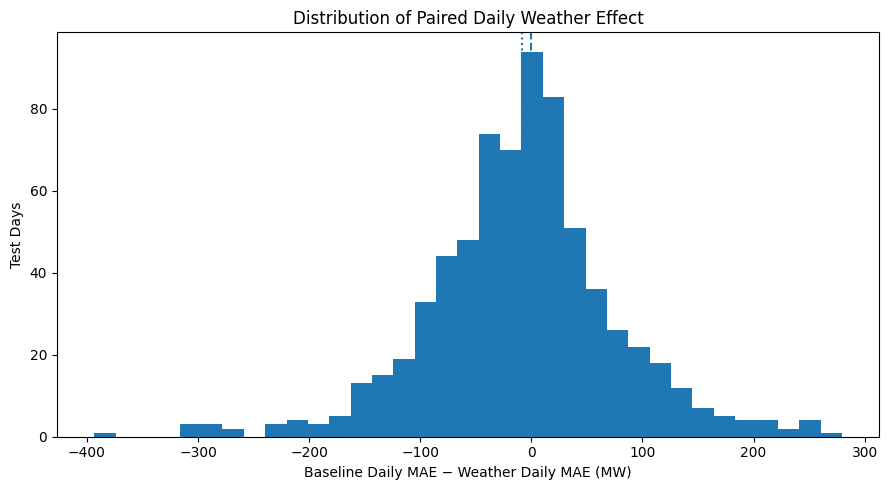



STEP W5 COMPLETED SUCCESSFULLY

A. PRIMARY MODEL
Frozen Ridge
Features: 165
151 load/history + 14 calendar
Alpha: 10
MAE: 437.156 MW
RMSE: 648.567 MW
MAPE: 3.778 %

B. WEATHER EXTENSION
Weather features: 89
Total features: 254
Validation MAE: 397.841 MW
Test MAE: 445.875 MW
Test MAE change vs frozen Ridge: -8.718 MW

C. STATISTICAL EVIDENCE
7-day bootstrap CI: -16.876 to -0.644
14-day bootstrap CI: -17.745 to -0.14
HAC-7 p: 0.03989
HAC-14 p: 0.05834

D. FINAL DECISION
Frozen Ridge remains the final model.
Historical weather is retained as an extension / ablation study.

Publication package:
/content/drive/MyDrive/Load_Forecasting_Paper/results/publication_package_weather_extension

Excel workbook:
/content/drive/MyDrive/Load_Forecasting_Paper/results/publication_package_weather_extension/weather_extension_publication_tables.xlsx

Results and discussion:
/content/drive/MyDrive/Load_Forecasting_Paper/results/publication_package_weather_extension/weather_extension_results_discussion.md


In [ ]:
# ======================================================================
# STEP W5
# PUBLICATION PACKAGE UPDATE — WEATHER EXTENSION
#
# PURPOSE
# -------
# Integrate W0-W4 weather-extension results into a publication-ready
# supplementary package WITHOUT modifying the frozen primary model.
#
# PRIMARY MODEL REMAINS:
#   Ridge alpha = 10
#   165 features
#   151 load/history + 14 calendar
#
# WEATHER EXTENSION:
#   89 strictly causal historical-weather features
#   254 total candidate features
#
# IMPORTANT:
#   Weather results are an extension / ablation study.
#   Weather is NOT incorporated into the frozen final model.
#
# OUTPUTS
# -------
# 1. Excel workbook with publication tables
# 2. Manuscript-ready weather Results/Discussion text
# 3. Weather claims registry
# 4. Publication figures
# 5. Final prediction table
# 6. README
# 7. Summary JSON
# ======================================================================


# ======================================================================
# 0. IMPORTS
# ======================================================================

import json
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from IPython.display import display


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 320)


print("=" * 125)
print("STEP W5: PUBLICATION PACKAGE — WEATHER EXTENSION")
print("=" * 125)


# ======================================================================
# 1. MOUNT DRIVE
# ======================================================================

drive.mount(
    "/content/drive"
)


# ======================================================================
# 2. PROJECT PATHS
# ======================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Load_Forecasting_Paper"
)


WEATHER_RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "weather_extension"
)


ML_RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "ml_baselines"
)


PUBLICATION_DIR = (
    PROJECT_ROOT
    / "results"
    / "publication_package_weather_extension"
)


PUBLICATION_FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "publication_package_weather_extension"
)


PUBLICATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PUBLICATION_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ======================================================================
# 3. INPUT FILES
# ======================================================================

WEATHER_LEADERBOARD_FILE = (
    WEATHER_RESULT_DIR
    / "weather_test_leaderboard.csv"
)


VALIDATION_COMPARISON_FILE = (
    WEATHER_RESULT_DIR
    / "weather_validation_comparison.csv"
)


BOOTSTRAP_FILE = (
    WEATHER_RESULT_DIR
    / "weather_paired_block_bootstrap.csv"
)


HAC_FILE = (
    WEATHER_RESULT_DIR
    / "weather_paired_hac_tests.csv"
)


ABLATION_FILE = (
    WEATHER_RESULT_DIR
    / "weather_feature_group_ablation.csv"
)


HOURLY_FILE = (
    WEATHER_RESULT_DIR
    / "weather_hourly_comparison.csv"
)


MONTHLY_FILE = (
    WEATHER_RESULT_DIR
    / "weather_monthly_effect.csv"
)


DAILY_FILE = (
    WEATHER_RESULT_DIR
    / "weather_daily_paired_errors.csv"
)


PREDICTIONS_FILE = (
    WEATHER_RESULT_DIR
    / "weather_vs_baseline_test_predictions.csv"
)


W3_SUMMARY_FILE = (
    WEATHER_RESULT_DIR
    / "stepW3_summary.json"
)


W4_SUMMARY_FILE = (
    WEATHER_RESULT_DIR
    / "stepW4_summary.json"
)


MAIN_LEADERBOARD_FILE = (
    ML_RESULT_DIR
    / "final_test_leaderboard.csv"
)


REQUIRED_FILES = [

    WEATHER_LEADERBOARD_FILE,
    VALIDATION_COMPARISON_FILE,
    BOOTSTRAP_FILE,
    HAC_FILE,
    ABLATION_FILE,
    HOURLY_FILE,
    MONTHLY_FILE,
    DAILY_FILE,
    PREDICTIONS_FILE,
    W3_SUMMARY_FILE,
    W4_SUMMARY_FILE

]


print("\nRequired weather files:")


for path in REQUIRED_FILES:

    print(
        path,
        "->",
        path.exists()
    )

    if not path.exists():

        raise FileNotFoundError(
            f"Required file missing: {path}"
        )


# ======================================================================
# 4. LOAD RESULTS
# ======================================================================

weather_leaderboard = pd.read_csv(
    WEATHER_LEADERBOARD_FILE
)


validation_comparison = pd.read_csv(
    VALIDATION_COMPARISON_FILE
)


bootstrap = pd.read_csv(
    BOOTSTRAP_FILE
)


hac = pd.read_csv(
    HAC_FILE
)


ablation = pd.read_csv(
    ABLATION_FILE
)


hourly = pd.read_csv(
    HOURLY_FILE
)


monthly = pd.read_csv(
    MONTHLY_FILE
)


daily = pd.read_csv(
    DAILY_FILE
)


predictions = pd.read_csv(
    PREDICTIONS_FILE
)


daily["target_date"] = pd.to_datetime(
    daily["target_date"]
)


predictions["target_date"] = pd.to_datetime(
    predictions["target_date"]
)


with open(
    W3_SUMMARY_FILE,
    "r"
) as file:

    w3_summary = json.load(
        file
    )


with open(
    W4_SUMMARY_FILE,
    "r"
) as file:

    w4_summary = json.load(
        file
    )


if MAIN_LEADERBOARD_FILE.exists():

    main_leaderboard = pd.read_csv(
        MAIN_LEADERBOARD_FILE
    )

else:

    main_leaderboard = pd.DataFrame()


# ======================================================================
# 5. EXTRACT PRIMARY RESULTS
# ======================================================================

baseline_row = (

    weather_leaderboard.loc[

        weather_leaderboard[
            "model"
        ]
        ==
        "Frozen_Ridge_165"

    ]

    .iloc[0]
)


weather_row = (

    weather_leaderboard.loc[

        weather_leaderboard[
            "model"
        ]
        ==
        "Ridge_Plus_Historical_Weather"

    ]

    .iloc[0]
)


BASELINE_MAE = float(
    baseline_row[
        "MAE_MW"
    ]
)


BASELINE_RMSE = float(
    baseline_row[
        "RMSE_MW"
    ]
)


BASELINE_MAPE = float(
    baseline_row[
        "MAPE_percent"
    ]
)


WEATHER_MAE = float(
    weather_row[
        "MAE_MW"
    ]
)


WEATHER_RMSE = float(
    weather_row[
        "RMSE_MW"
    ]
)


WEATHER_MAPE = float(
    weather_row[
        "MAPE_percent"
    ]
)


WEATHER_DELTA = (
    BASELINE_MAE
    -
    WEATHER_MAE
)


WEATHER_SKILL = (

    100
    *
    (
        1
        -
        WEATHER_MAE
        /
        BASELINE_MAE
    )

)


# ======================================================================
# 6. VALIDATION RESULTS
# ======================================================================

baseline_val = (

    validation_comparison.loc[

        validation_comparison[
            "model"
        ]
        ==
        "Frozen_Ridge_165"

    ]

    .iloc[0]
)


weather_val = (

    validation_comparison.loc[

        validation_comparison[
            "model"
        ]
        ==
        "Ridge_Plus_Weather"

    ]

    .iloc[0]
)


BASELINE_VAL_MAE = float(
    baseline_val[
        "MAE_MW"
    ]
)


WEATHER_VAL_MAE = float(
    weather_val[
        "MAE_MW"
    ]
)


VALIDATION_IMPROVEMENT = (

    BASELINE_VAL_MAE
    -
    WEATHER_VAL_MAE
)


# ======================================================================
# 7. STATISTICAL RESULTS
# ======================================================================

bootstrap7 = (

    bootstrap.loc[

        bootstrap[
            "block_length"
        ]
        ==
        7

    ]

    .iloc[0]
)


bootstrap14 = (

    bootstrap.loc[

        bootstrap[
            "block_length"
        ]
        ==
        14

    ]

    .iloc[0]
)


hac7 = (

    hac.loc[

        hac[
            "HAC_lag"
        ]
        ==
        7

    ]

    .iloc[0]
)


hac14 = (

    hac.loc[

        hac[
            "HAC_lag"
        ]
        ==
        14

    ]

    .iloc[0]
)


BOOT7_LOW = float(
    bootstrap7[
        "CI_lower_MW"
    ]
)


BOOT7_HIGH = float(
    bootstrap7[
        "CI_upper_MW"
    ]
)


BOOT14_LOW = float(
    bootstrap14[
        "CI_lower_MW"
    ]
)


BOOT14_HIGH = float(
    bootstrap14[
        "CI_upper_MW"
    ]
)


HAC7_P = float(
    hac7[
        "p_value"
    ]
)


HAC14_P = float(
    hac14[
        "p_value"
    ]
)


# ======================================================================
# 8. TABLE 1 — FINAL MODEL STATUS
# ======================================================================

table1 = pd.DataFrame([

    {

        "Model":
            "Frozen Ridge",

        "Status":
            "Primary final model",

        "Load_History_Features":
            151,

        "Calendar_Features":
            14,

        "Weather_Features":
            0,

        "Total_Features":
            165,

        "Alpha":
            10.0,

        "Test_MAE_MW":
            BASELINE_MAE,

        "Test_RMSE_MW":
            BASELINE_RMSE,

        "Test_MAPE_percent":
            BASELINE_MAPE

    },

    {

        "Model":
            "Ridge + Historical Weather",

        "Status":
            "Extension / ablation only",

        "Load_History_Features":
            151,

        "Calendar_Features":
            14,

        "Weather_Features":
            89,

        "Total_Features":
            254,

        "Alpha":
            float(
                weather_row[
                    "alpha"
                ]
            ),

        "Test_MAE_MW":
            WEATHER_MAE,

        "Test_RMSE_MW":
            WEATHER_RMSE,

        "Test_MAPE_percent":
            WEATHER_MAPE

    }

])


# ======================================================================
# 9. TABLE 2 — WEATHER EXTENSION
# ======================================================================

table2 = pd.DataFrame([

    {

        "Model":
            "Frozen Ridge",

        "Features":
            165,

        "Validation_MAE_MW":
            BASELINE_VAL_MAE,

        "Test_MAE_MW":
            BASELINE_MAE,

        "Test_RMSE_MW":
            BASELINE_RMSE,

        "Test_MAPE_percent":
            BASELINE_MAPE,

        "Test_MAE_Improvement_vs_Frozen_MW":
            0.0,

        "Relative_Test_Skill_percent":
            0.0

    },

    {

        "Model":
            "Ridge + Historical Weather",

        "Features":
            254,

        "Validation_MAE_MW":
            WEATHER_VAL_MAE,

        "Test_MAE_MW":
            WEATHER_MAE,

        "Test_RMSE_MW":
            WEATHER_RMSE,

        "Test_MAPE_percent":
            WEATHER_MAPE,

        "Test_MAE_Improvement_vs_Frozen_MW":
            WEATHER_DELTA,

        "Relative_Test_Skill_percent":
            WEATHER_SKILL

    }

])


# ======================================================================
# 10. TABLE 3 — STATISTICAL EVIDENCE
# ======================================================================

table3 = pd.DataFrame([

    {

        "Method":
            "7-day moving-block bootstrap",

        "Mean_Difference_MW":
            float(
                bootstrap7[
                    "mean_difference_MW"
                ]
            ),

        "CI_Lower_MW":
            BOOT7_LOW,

        "CI_Upper_MW":
            BOOT7_HIGH,

        "P_Value":
            np.nan,

        "Interpretation":
            (
                "95% CI below zero; historical-weather "
                "model has larger daily MAE."
            )

    },

    {

        "Method":
            "14-day moving-block bootstrap",

        "Mean_Difference_MW":
            float(
                bootstrap14[
                    "mean_difference_MW"
                ]
            ),

        "CI_Lower_MW":
            BOOT14_LOW,

        "CI_Upper_MW":
            BOOT14_HIGH,

        "P_Value":
            np.nan,

        "Interpretation":
            (
                "95% CI below zero; deterioration persists "
                "under longer dependence blocks."
            )

    },

    {

        "Method":
            "Newey-West HAC lag 7",

        "Mean_Difference_MW":
            float(
                hac7[
                    "mean_difference_MW"
                ]
            ),

        "CI_Lower_MW":
            np.nan,

        "CI_Upper_MW":
            np.nan,

        "P_Value":
            HAC7_P,

        "Interpretation":
            (
                "Evidence against zero mean loss difference "
                "at the 5% level."
            )

    },

    {

        "Method":
            "Newey-West HAC lag 14",

        "Mean_Difference_MW":
            float(
                hac14[
                    "mean_difference_MW"
                ]
            ),

        "CI_Lower_MW":
            np.nan,

        "CI_Upper_MW":
            np.nan,

        "P_Value":
            HAC14_P,

        "Interpretation":
            (
                "Does not cross the conventional 5% "
                "significance threshold."
            )

    }

])


# ======================================================================
# 11. TABLE 4 — WEATHER ABLATION
# ======================================================================

table4 = (

    ablation[

        [
            "Removed_Group",
            "Features_Remaining",
            "Validation_MAE_MW",
            "Test_MAE_MW",
            "Test_RMSE_MW",
            "Test_MAPE_percent",
            "Delta_Validation_MAE_vs_FullWeather_MW",
            "Delta_Test_MAE_vs_FullWeather_MW"

        ]

    ]

    .copy()

)


# ======================================================================
# 12. TABLE 5 — WEATHER HORIZON EFFECT
# ======================================================================

table5 = hourly.copy()


# ======================================================================
# 13. TABLE 6 — MONTHLY WEATHER EFFECT
# ======================================================================

table6 = monthly.copy()


# ======================================================================
# 14. DISPLAY CORE TABLES
# ======================================================================

print("\n" + "=" * 125)
print("TABLE 1 — FINAL MODEL STATUS")
print("=" * 125)

display(
    table1.round(4)
)


print("\n" + "=" * 125)
print("TABLE 2 — WEATHER EXTENSION")
print("=" * 125)

display(
    table2.round(4)
)


print("\n" + "=" * 125)
print("TABLE 3 — WEATHER STATISTICAL EVIDENCE")
print("=" * 125)

display(
    table3.round(5)
)


print("\n" + "=" * 125)
print("TABLE 4 — POST-HOC WEATHER ABLATION")
print("=" * 125)

display(
    table4.round(4)
)


# ======================================================================
# 15. SAVE CSV TABLES
# ======================================================================

TABLE_FILES = {

    "Table_Weather_01_Final_Model_Status.csv":
        table1,

    "Table_Weather_02_Extension_Performance.csv":
        table2,

    "Table_Weather_03_Statistical_Evidence.csv":
        table3,

    "Table_Weather_04_Feature_Ablation.csv":
        table4,

    "Table_Weather_05_Horizon_Effect.csv":
        table5,

    "Table_Weather_06_Monthly_Effect.csv":
        table6

}


for filename, dataframe in (
    TABLE_FILES.items()
):

    dataframe.to_csv(

        PUBLICATION_DIR
        /
        filename,

        index=False

    )


# ======================================================================
# 16. CREATE EXCEL WORKBOOK
# ======================================================================

EXCEL_FILE = (

    PUBLICATION_DIR
    /
    "weather_extension_publication_tables.xlsx"

)


with pd.ExcelWriter(

    EXCEL_FILE,

    engine="openpyxl"

) as writer:

    table1.to_excel(

        writer,

        sheet_name=
            "Final Model Status",

        index=False

    )


    table2.to_excel(

        writer,

        sheet_name=
            "Weather Extension",

        index=False

    )


    table3.to_excel(

        writer,

        sheet_name=
            "Statistical Evidence",

        index=False

    )


    table4.to_excel(

        writer,

        sheet_name=
            "Weather Ablation",

        index=False

    )


    table5.to_excel(

        writer,

        sheet_name=
            "Hourly Effect",

        index=False

    )


    table6.to_excel(

        writer,

        sheet_name=
            "Monthly Effect",

        index=False

    )


    if not main_leaderboard.empty:

        main_leaderboard.to_excel(

            writer,

            sheet_name=
                "Original Leaderboard",

            index=False

        )


print(
    "\nExcel workbook created:"
)

print(
    EXCEL_FILE
)


# ======================================================================
# 17. FIGURE 1 — MODEL COMPARISON
# ======================================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


plt.bar(

    [
        "Frozen Ridge",
        "Ridge + Weather"
    ],

    [
        BASELINE_MAE,
        WEATHER_MAE
    ]

)


plt.ylabel(
    "Locked-Test MAE (MW)"
)


plt.title(
    "Historical Weather Extension"
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


FIG1 = (

    PUBLICATION_FIGURE_DIR
    /
    "Figure_W1_Weather_Model_Comparison.png"

)


plt.savefig(
    FIG1,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 18. FIGURE 2 — HORIZON-WISE MAE
# ======================================================================

plt.figure(
    figsize=(
        11,
        5
    )
)


plt.plot(

    hourly[
        "hour"
    ],

    hourly[
        "baseline_MAE_MW"
    ],

    marker="o",

    label=
        "Frozen Ridge"

)


plt.plot(

    hourly[
        "hour"
    ],

    hourly[
        "weather_MAE_MW"
    ],

    marker="o",

    label=
        "Ridge + Historical Weather"

)


plt.xlabel(
    "Forecast Hour"
)


plt.ylabel(
    "MAE (MW)"
)


plt.title(
    "Horizon-Wise Forecast Error"
)


plt.xticks(
    range(
        1,
        24
    )
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()


FIG2 = (

    PUBLICATION_FIGURE_DIR
    /
    "Figure_W2_Hourly_Weather_Effect.png"

)


plt.savefig(
    FIG2,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 19. FIGURE 3 — MONTH-OF-YEAR EFFECT
# ======================================================================

plt.figure(
    figsize=(
        10,
        5
    )
)


plt.bar(

    monthly[
        "month"
    ],

    monthly[
        "mean_weather_improvement_MW"
    ]

)


plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel(
    "Month"
)


plt.ylabel(
    "Baseline MAE − Weather MAE (MW)"
)


plt.title(
    "Month-of-Year Effect of Historical Weather"
)


plt.xticks(
    range(
        1,
        13
    )
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


FIG3 = (

    PUBLICATION_FIGURE_DIR
    /
    "Figure_W3_Monthly_Weather_Effect.png"

)


plt.savefig(
    FIG3,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 20. FIGURE 4 — DAILY MEAN LOAD TIME SERIES
# ======================================================================
#
# To avoid cherry-picking an individual day, compare the DAILY MEAN
# observed profile and model forecasts over the complete locked test.
# ======================================================================

ACTUAL_COLUMNS = [

    column

    for column in predictions.columns

    if column.startswith(
        "actual_h"
    )

]


BASELINE_COLUMNS = [

    column

    for column in predictions.columns

    if column.startswith(
        "baseline_h"
    )

]


WEATHER_COLUMNS = [

    column

    for column in predictions.columns

    if column.startswith(
        "weather_h"
    )

]


predictions[
    "actual_daily_mean"
] = (

    predictions[
        ACTUAL_COLUMNS
    ]
    .mean(
        axis=1
    )

)


predictions[
    "baseline_daily_mean"
] = (

    predictions[
        BASELINE_COLUMNS
    ]
    .mean(
        axis=1
    )

)


predictions[
    "weather_daily_mean"
] = (

    predictions[
        WEATHER_COLUMNS
    ]
    .mean(
        axis=1
    )

)


plt.figure(
    figsize=(
        14,
        5
    )
)


plt.plot(

    predictions[
        "target_date"
    ],

    predictions[
        "actual_daily_mean"
    ],

    linewidth=0.9,

    label=
        "Observed"

)


plt.plot(

    predictions[
        "target_date"
    ],

    predictions[
        "baseline_daily_mean"
    ],

    linewidth=0.8,

    label=
        "Frozen Ridge"

)


plt.plot(

    predictions[
        "target_date"
    ],

    predictions[
        "weather_daily_mean"
    ],

    linewidth=0.8,

    label=
        "Ridge + Historical Weather"

)


plt.xlabel(
    "Target Date"
)


plt.ylabel(
    "Daily Mean Load (MW)"
)


plt.title(
    "Locked-Test Observed and Forecast Daily Mean Load"
)


plt.legend()


plt.grid(
    alpha=0.20
)


plt.tight_layout()


FIG4 = (

    PUBLICATION_FIGURE_DIR
    /
    "Figure_W4_Test_Daily_Mean_Forecasts.png"

)


plt.savefig(
    FIG4,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 21. FIGURE 5 — DAILY MAE DIFFERENCE DISTRIBUTION
# ======================================================================

difference = (

    daily[
        "baseline_daily_MAE_MW"
    ]

    -

    daily[
        "weather_daily_MAE_MW"
    ]

)


plt.figure(
    figsize=(
        9,
        5
    )
)


plt.hist(

    difference,

    bins=35

)


plt.axvline(
    0,
    linestyle="--"
)


plt.axvline(

    difference.mean(),

    linestyle=":"

)


plt.xlabel(
    "Baseline Daily MAE − Weather Daily MAE (MW)"
)


plt.ylabel(
    "Test Days"
)


plt.title(
    "Distribution of Paired Daily Weather Effect"
)


plt.tight_layout()


FIG5 = (

    PUBLICATION_FIGURE_DIR
    /
    "Figure_W5_Daily_Loss_Difference.png"

)


plt.savefig(
    FIG5,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ======================================================================
# 22. COPY FINAL PREDICTIONS INTO PUBLICATION PACKAGE
# ======================================================================

FINAL_PREDICTION_FILE = (

    PUBLICATION_DIR
    /
    "weather_extension_test_predictions.csv"

)


predictions.to_csv(

    FINAL_PREDICTION_FILE,

    index=False

)


# ======================================================================
# 23. MANUSCRIPT-SAFE CLAIMS REGISTRY
# ======================================================================

CLAIMS_TEXT = f"""
# WEATHER EXTENSION — MANUSCRIPT-SAFE CLAIMS

## Study design

1. The primary forecasting model remains the frozen Ridge regression
   model with alpha=10.

2. The frozen model uses 165 predictors:
   151 historical-load/statistical predictors and 14 calendar
   predictors.

3. The historical-weather extension introduced 89 additional
   strictly causal weather predictors, yielding 254 total candidate
   predictors.

4. Only weather observed on target day D-1 or earlier was used.
   Target-day realized weather was not used.

5. Weather observations were derived from a consistent ERA5
   reanalysis series for four Bangladesh cities and aggregated to
   an equal-city spatial representation.

## Validation

6. On the 2023 validation period, the frozen Ridge achieved
   MAE = {BASELINE_VAL_MAE:.3f} MW.

7. The historical-weather Ridge achieved
   MAE = {WEATHER_VAL_MAE:.3f} MW.

8. Historical weather therefore reduced validation MAE by
   {VALIDATION_IMPROVEMENT:.3f} MW.

## Locked test

9. On the locked 2024-2026 test period, the frozen Ridge achieved
   MAE = {BASELINE_MAE:.3f} MW.

10. The historical-weather Ridge achieved
    MAE = {WEATHER_MAE:.3f} MW.

11. Historical-weather augmentation changed MAE by
    {WEATHER_DELTA:.3f} MW relative to the frozen model.

12. Because this quantity is negative, weather increased rather
    than reduced locked-test MAE.

13. Relative test skill of the weather model versus frozen Ridge was
    {WEATHER_SKILL:.3f}%.

## Dependence-aware statistical assessment

14. The paired loss was calculated once per test day as the mean
    absolute error across all 23 forecast horizons.

15. The 7-day moving-block-bootstrap 95% CI for
    baseline MAE minus weather-model MAE was
    [{BOOT7_LOW:.3f}, {BOOT7_HIGH:.3f}] MW.

16. The 14-day block-bootstrap 95% CI was
    [{BOOT14_LOW:.3f}, {BOOT14_HIGH:.3f}] MW.

17. Both bootstrap intervals lie below zero, supporting deterioration
    of the historical-weather specification on the locked test.

18. The Newey-West HAC lag-7 test gave p={HAC7_P:.4f}.

19. The Newey-West HAC lag-14 test gave p={HAC14_P:.4f}.

20. Therefore inferential evidence is stronger under the 7-day HAC
    specification, while the 14-day HAC result does not cross the
    conventional 0.05 threshold.

## Ablation interpretation

21. Weather feature-group ablations are post-hoc diagnostics.

22. They must not be used to redefine the frozen final model using
    the already-observed locked test.

23. Removing all weather returned the original frozen Ridge and
    produced lower test MAE than the complete weather model.

## Claims to avoid

24. Do NOT claim that weather is generally useless for Bangladesh
    electricity forecasting.

25. Do NOT claim that ERA5 is equivalent to an operational target-day
    weather forecast.

26. Do NOT claim that the weather degradation proves a causal effect.

27. Do NOT select a test-discovered subset of weather features and
    report it as a new confirmatory final model.

28. Preferred conclusion:
    "Under the tested strictly causal historical-weather
    representation and linear Ridge specification, weather did not
    improve chronological generalization beyond the load-history and
    calendar baseline."
"""


CLAIMS_FILE = (

    PUBLICATION_DIR
    /
    "weather_extension_manuscript_claims.md"

)


CLAIMS_FILE.write_text(

    CLAIMS_TEXT,

    encoding="utf-8"

)


# ======================================================================
# 24. RESULTS + DISCUSSION DRAFT
# ======================================================================

RESULTS_TEXT = f"""
# Weather Extension: Results and Discussion

To examine whether meteorological information provided incremental
predictive value beyond recent load dynamics, 89 strictly causal
historical-weather predictors were appended to the frozen 165-feature
Ridge specification. The resulting model therefore contained 254
candidate predictors. Weather inputs were restricted to observations
available through the previous day; realized target-day weather was
excluded.

On the 2023 validation period, the historical-weather model reduced
MAE from {BASELINE_VAL_MAE:.2f} MW to {WEATHER_VAL_MAE:.2f} MW, an
improvement of {VALIDATION_IMPROVEMENT:.2f} MW. However, this advantage
did not persist on the locked 2024-2026 evaluation period. The frozen
Ridge model achieved an MAE of {BASELINE_MAE:.2f} MW, whereas the
weather-enhanced specification produced {WEATHER_MAE:.2f} MW. Thus,
historical-weather augmentation increased test MAE by
{abs(WEATHER_DELTA):.2f} MW ({abs(WEATHER_SKILL):.2f}% relative
deterioration).

Dependence-aware paired analysis supported the same direction. The
7-day moving-block-bootstrap 95% confidence interval for the daily
difference defined as baseline MAE minus weather-model MAE was
[{BOOT7_LOW:.2f}, {BOOT7_HIGH:.2f}] MW, while the corresponding
14-day interval was [{BOOT14_LOW:.2f}, {BOOT14_HIGH:.2f}] MW.
Both intervals were below zero. The Newey-West HAC test yielded
p={HAC7_P:.4f} at lag 7 and p={HAC14_P:.4f} at lag 14, indicating
stronger evidence under the shorter dependence specification and
borderline evidence under the longer-lag robustness setting.

The result suggests that the tested historical-weather representation
did not provide robust incremental information beyond the extensive
load-history, rolling-statistic, and calendar predictors. One plausible
explanation is that recent load observations already encode substantial
weather-sensitive demand behavior. In addition, spatial averaging
across four cities may attenuate localized meteorological effects, and
the linear Ridge formulation may not fully represent nonlinear
temperature-humidity-season interactions.

Post-hoc weather-group ablation indicated that several groups were
redundant or potentially destabilizing on the locked test. These
ablations are diagnostic only, because the test period had already
been observed and therefore cannot be used for confirmatory feature
selection.

Consequently, the frozen 165-feature Ridge model remains the primary
forecasting specification. The weather experiment is retained as an
extension study demonstrating that additional meteorological
predictors do not automatically improve out-of-time generalization
when strong historical-load information is already available.
"""


RESULTS_FILE = (

    PUBLICATION_DIR
    /
    "weather_extension_results_discussion.md"

)


RESULTS_FILE.write_text(

    RESULTS_TEXT,

    encoding="utf-8"

)


# ======================================================================
# 25. FIGURE MANIFEST
# ======================================================================

figure_manifest = pd.DataFrame([

    {

        "Figure":
            "Weather Figure W1",

        "File":
            str(
                FIG1
            ),

        "Purpose":
            "Locked-test MAE comparison between frozen and weather-enhanced Ridge."

    },

    {

        "Figure":
            "Weather Figure W2",

        "File":
            str(
                FIG2
            ),

        "Purpose":
            "Forecast-horizon-specific effect of historical weather."

    },

    {

        "Figure":
            "Weather Figure W3",

        "File":
            str(
                FIG3
            ),

        "Purpose":
            "Month-of-year variation in the historical-weather effect."

    },

    {

        "Figure":
            "Weather Figure W4",

        "File":
            str(
                FIG4
            ),

        "Purpose":
            "Observed and predicted daily mean load over the complete locked test."

    },

    {

        "Figure":
            "Weather Figure W5",

        "File":
            str(
                FIG5
            ),

        "Purpose":
            "Distribution of paired daily loss differences."

    }

])


FIGURE_MANIFEST_FILE = (

    PUBLICATION_DIR
    /
    "weather_figure_manifest.csv"

)


figure_manifest.to_csv(

    FIGURE_MANIFEST_FILE,

    index=False

)


# ======================================================================
# 26. README
# ======================================================================

README_TEXT = f"""
WEATHER EXTENSION PUBLICATION PACKAGE
=====================================

Primary final model
-------------------
Model:
Frozen Ridge

Alpha:
10

Feature count:
165

Feature composition:
151 load/history/statistical features
14 calendar features

Locked-test performance:
MAE  = {BASELINE_MAE:.3f} MW
RMSE = {BASELINE_RMSE:.3f} MW
MAPE = {BASELINE_MAPE:.4f}%


Historical-weather extension
----------------------------
Weather predictors:
89

Total predictors:
254

Validation MAE:
{WEATHER_VAL_MAE:.3f} MW

Locked-test MAE:
{WEATHER_MAE:.3f} MW

Change relative to frozen Ridge:
{WEATHER_DELTA:.3f} MW

Relative skill:
{WEATHER_SKILL:.3f}%


Dependence-aware inference
--------------------------
7-day bootstrap 95% CI:
[{BOOT7_LOW:.3f}, {BOOT7_HIGH:.3f}] MW

14-day bootstrap 95% CI:
[{BOOT14_LOW:.3f}, {BOOT14_HIGH:.3f}] MW

HAC lag-7 p:
{HAC7_P:.6f}

HAC lag-14 p:
{HAC14_P:.6f}


Final interpretation
--------------------
The historical-weather extension did not improve locked-test
generalization under the tested Ridge specification.

The frozen 165-feature Ridge remains the primary model.

Weather ablations are POST-HOC diagnostics and must not be used to
select a replacement final model from the locked test.


Files
-----
weather_extension_publication_tables.xlsx

Table_Weather_01_Final_Model_Status.csv
Table_Weather_02_Extension_Performance.csv
Table_Weather_03_Statistical_Evidence.csv
Table_Weather_04_Feature_Ablation.csv
Table_Weather_05_Horizon_Effect.csv
Table_Weather_06_Monthly_Effect.csv

weather_extension_manuscript_claims.md
weather_extension_results_discussion.md
weather_extension_test_predictions.csv
weather_figure_manifest.csv
stepW5_summary.json
"""


README_FILE = (

    PUBLICATION_DIR
    /
    "README_weather_extension.txt"

)


README_FILE.write_text(

    README_TEXT,

    encoding="utf-8"

)


# ======================================================================
# 27. FINAL SUMMARY JSON
# ======================================================================

FINAL_SUMMARY = {

    "step":
        "W5",

    "primary_model":
        "Frozen Ridge",

    "primary_alpha":
        10.0,

    "primary_feature_count":
        165,

    "primary_load_history_feature_count":
        151,

    "primary_calendar_feature_count":
        14,

    "weather_feature_count":
        89,

    "weather_combined_feature_count":
        254,

    "baseline_validation_MAE_MW":
        BASELINE_VAL_MAE,

    "weather_validation_MAE_MW":
        WEATHER_VAL_MAE,

    "baseline_test_MAE_MW":
        BASELINE_MAE,

    "weather_test_MAE_MW":
        WEATHER_MAE,

    "weather_test_improvement_MW":
        WEATHER_DELTA,

    "weather_test_skill_percent":
        WEATHER_SKILL,

    "bootstrap7_CI_MW":
        [
            BOOT7_LOW,
            BOOT7_HIGH
        ],

    "bootstrap14_CI_MW":
        [
            BOOT14_LOW,
            BOOT14_HIGH
        ],

    "HAC7_p_value":
        HAC7_P,

    "HAC14_p_value":
        HAC14_P,

    "final_model_changed":
        False,

    "weather_role":
        "extension_and_post_hoc_ablation",

    "recommended_conclusion":
        (
            "Under the tested strictly causal historical-weather "
            "representation and Ridge specification, weather did "
            "not improve locked-test chronological generalization."
        )

}


SUMMARY_FILE = (

    PUBLICATION_DIR
    /
    "stepW5_summary.json"

)


with open(
    SUMMARY_FILE,
    "w"
) as file:

    json.dump(

        FINAL_SUMMARY,

        file,

        indent=4

    )


# ======================================================================
# 28. FINAL VALIDATION
# ======================================================================

assert abs(
    BASELINE_MAE
    -
    437.1565
) < 0.1


assert (
    WEATHER_MAE
    >
    BASELINE_MAE
)


assert (
    BOOT7_HIGH
    <
    0
)


assert (
    BOOT14_HIGH
    <
    0
)


assert (
    HAC7_P
    <
    0.05
)


# HAC-14 is intentionally NOT asserted <0.05 because W4 gave ~0.058.


print("\n")
print("=" * 125)
print("STEP W5 COMPLETED SUCCESSFULLY")
print("=" * 125)


print("\nA. PRIMARY MODEL")

print(
    "Frozen Ridge"
)

print(
    "Features: 165"
)

print(
    "151 load/history + 14 calendar"
)

print(
    "Alpha: 10"
)

print(
    "MAE:",
    round(
        BASELINE_MAE,
        3
    ),
    "MW"
)

print(
    "RMSE:",
    round(
        BASELINE_RMSE,
        3
    ),
    "MW"
)

print(
    "MAPE:",
    round(
        BASELINE_MAPE,
        3
    ),
    "%"
)


print("\nB. WEATHER EXTENSION")

print(
    "Weather features: 89"
)

print(
    "Total features: 254"
)

print(
    "Validation MAE:",
    round(
        WEATHER_VAL_MAE,
        3
    ),
    "MW"
)

print(
    "Test MAE:",
    round(
        WEATHER_MAE,
        3
    ),
    "MW"
)

print(
    "Test MAE change vs frozen Ridge:",
    round(
        WEATHER_DELTA,
        3
    ),
    "MW"
)


print("\nC. STATISTICAL EVIDENCE")

print(
    "7-day bootstrap CI:",
    round(
        BOOT7_LOW,
        3
    ),
    "to",
    round(
        BOOT7_HIGH,
        3
    )
)


print(
    "14-day bootstrap CI:",
    round(
        BOOT14_LOW,
        3
    ),
    "to",
    round(
        BOOT14_HIGH,
        3
    )
)


print(
    "HAC-7 p:",
    round(
        HAC7_P,
        5
    )
)


print(
    "HAC-14 p:",
    round(
        HAC14_P,
        5
    )
)


print("\nD. FINAL DECISION")

print(
    "Frozen Ridge remains the final model."
)

print(
    "Historical weather is retained as an extension / ablation study."
)


print("\nPublication package:")

print(
    PUBLICATION_DIR
)


print("\nExcel workbook:")

print(
    EXCEL_FILE
)


print("\nResults and discussion:")

print(
    RESULTS_FILE
)


print("\nClaims registry:")

print(
    CLAIMS_FILE
)


print("\nFigures:")

print(
    PUBLICATION_FIGURE_DIR
)


print("=" * 125)